In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [4]:
#load dataset
df = pd.read_csv("C:/Users/ASUS ROG STRIX/OneDrive/Documents/netfilxdata.csv")

In [5]:
print(df.head())
print(df.shape)
print(df.columns)
print(df.info())
print(df.describe())

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

In [6]:
#check missing value
print(df.isnull().sum())

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [7]:
#handling missing values
df['director'].fillna('Unknown', inplace=True)
df['cast'].fillna('Unknown', inplace=True)
df['country'].fillna('Unknown', inplace=True)
df['rating'].fillna('Unknown', inplace=True)
df['duration'].fillna('Unknown', inplace=True)

C:\Users\ASUS ROG STRIX\AppData\Local\Temp\ipykernel_17032\1762842148.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['director'].fillna('Unknown', inplace=True)
C:\Users\ASUS ROG STRIX\AppData\Local\Temp\ipykernel_17032\1762842148.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through ch

0          90 min
1       2 Seasons
2        1 Season
3        1 Season
4       2 Seasons
          ...    
8802      158 min
8803    2 Seasons
8804       88 min
8805       88 min
8806      111 min
Name: duration, Length: 8807, dtype: str

In [8]:
#remove duplicate rows
df.drop_duplicates(inplace=True)

In [11]:
#convert date column
df['date_added'] = pd.to_datetime(df['date_added'],errors='coerce')

In [12]:
#create new features
#create year added column
df['year_added'] = df['date_added'].dt.year
#create month added column
df['month_added'] = df['date_added'].dt.month_name()

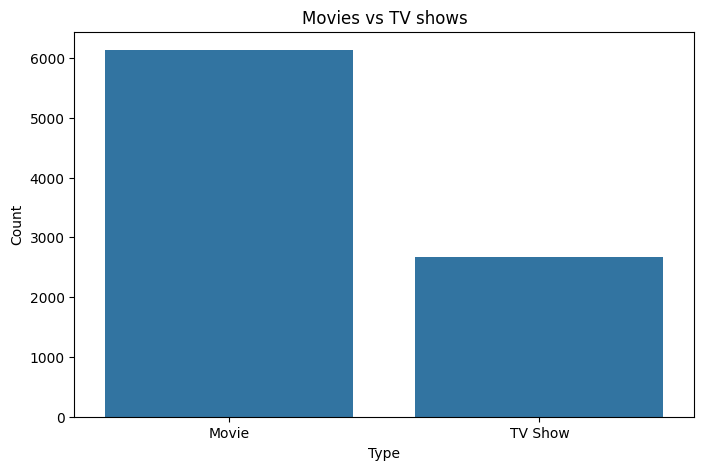

In [13]:
#Movies vs TV shows Analysis
plt.figure(figsize=(8,5))
sns.countplot(x="type", data=df)
plt.title("Movies vs TV shows")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

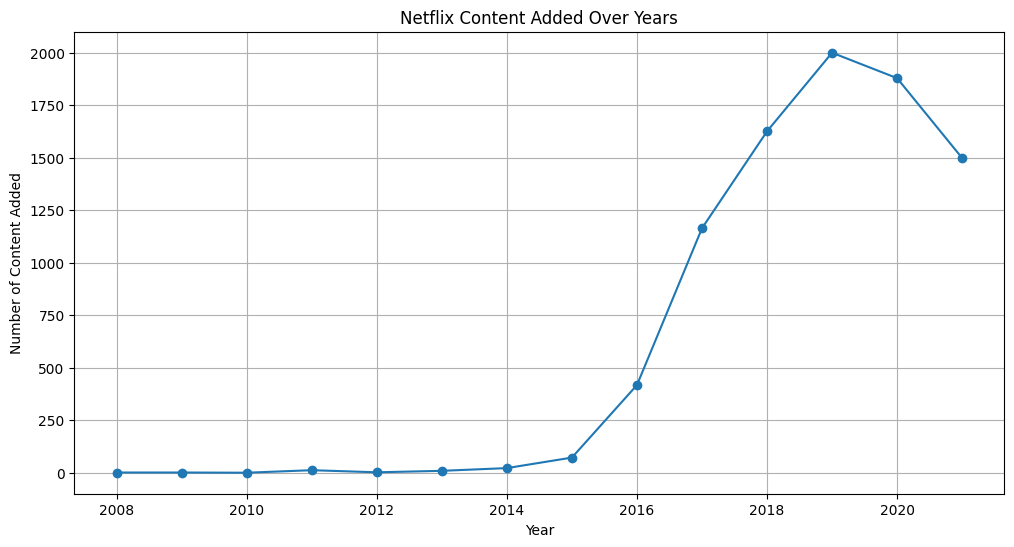

In [14]:
#content added over years(Trend Analysis)
yearly_content = df['year_added'].value_counts().sort_index()

plt.figure(figsize=(12,6))

plt.plot(yearly_content.index,
         yearly_content.values,
         marker='o')

plt.title('Netflix Content Added Over Years')
plt.xlabel('Year')
plt.ylabel('Number of Content Added')
plt.grid(True)

plt.show()

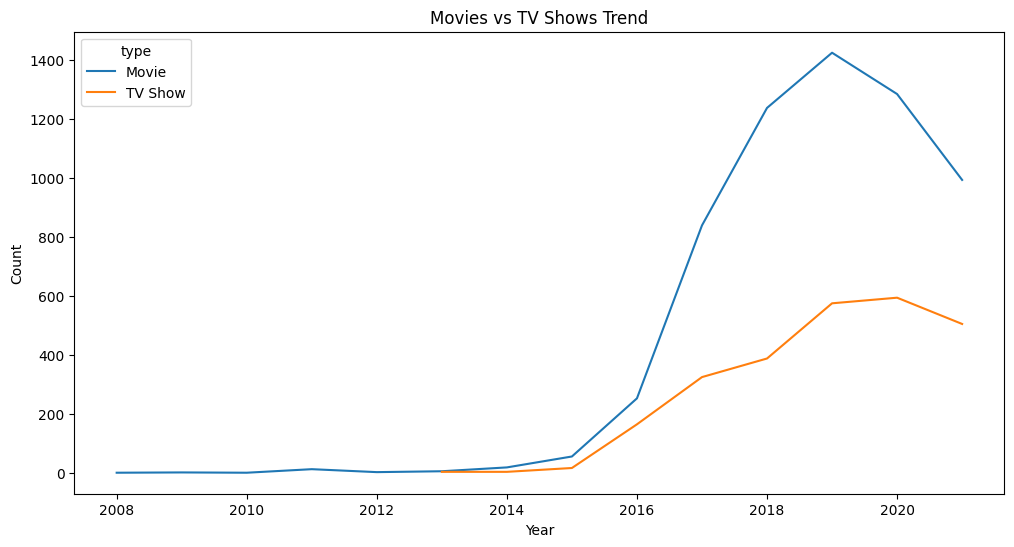

In [15]:
#Movies vs TV shows Trend analysis
content_trend = df.groupby(['year_added', 'type']).size().unstack()

content_trend.plot(figsize=(12,6))

plt.title('Movies vs TV Shows Trend')
plt.xlabel('Year')
plt.ylabel('Count')

plt.show()

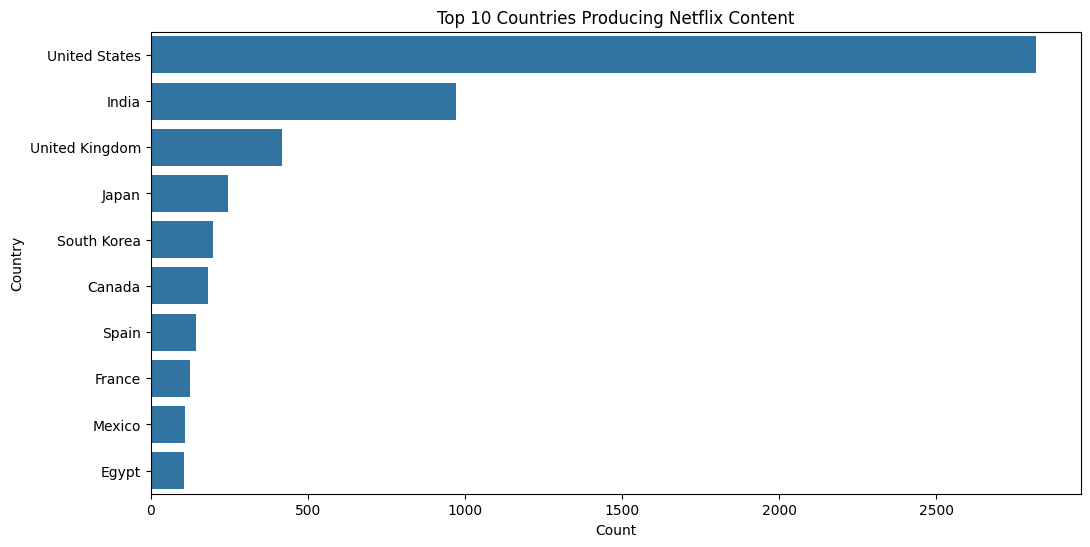

In [16]:
#top 10 countries analysis
top_countries = df['country'].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(x=top_countries.values,
            y=top_countries.index)

plt.title('Top 10 Countries Producing Netflix Content')
plt.xlabel('Count')
plt.ylabel('Country')

plt.show()

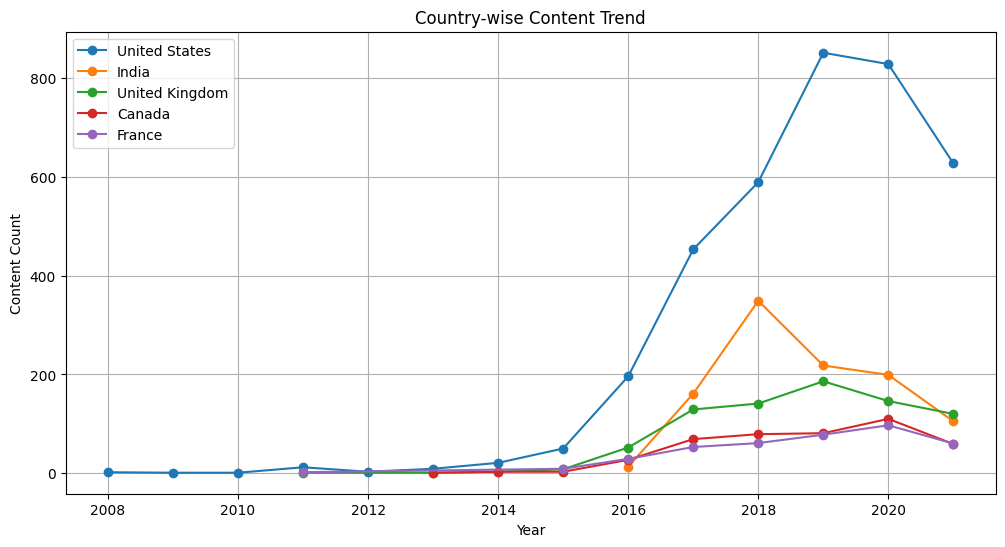

In [17]:
#country wise trend analysis
country_df = df.copy()

country_df['country'] = country_df['country'].str.split(',')

country_df = country_df.explode('country')

country_df['country'] = country_df['country'].str.strip()

# Top 5 countries

top_country_names = country_df['country'].value_counts().head(5).index

country_trend = country_df.groupby(
    ['year_added', 'country']
).size().reset_index(name='count')

filtered_country = country_trend[
    country_trend['country'].isin(top_country_names)
]

plt.figure(figsize=(12,6))

for country in top_country_names:
    data = filtered_country[
        filtered_country['country'] == country
    ]

    plt.plot(data['year_added'],
             data['count'],
             marker='o',
             label=country)

plt.title('Country-wise Content Trend')
plt.xlabel('Year')
plt.ylabel('Content Count')
plt.legend()
plt.grid(True)

plt.show()

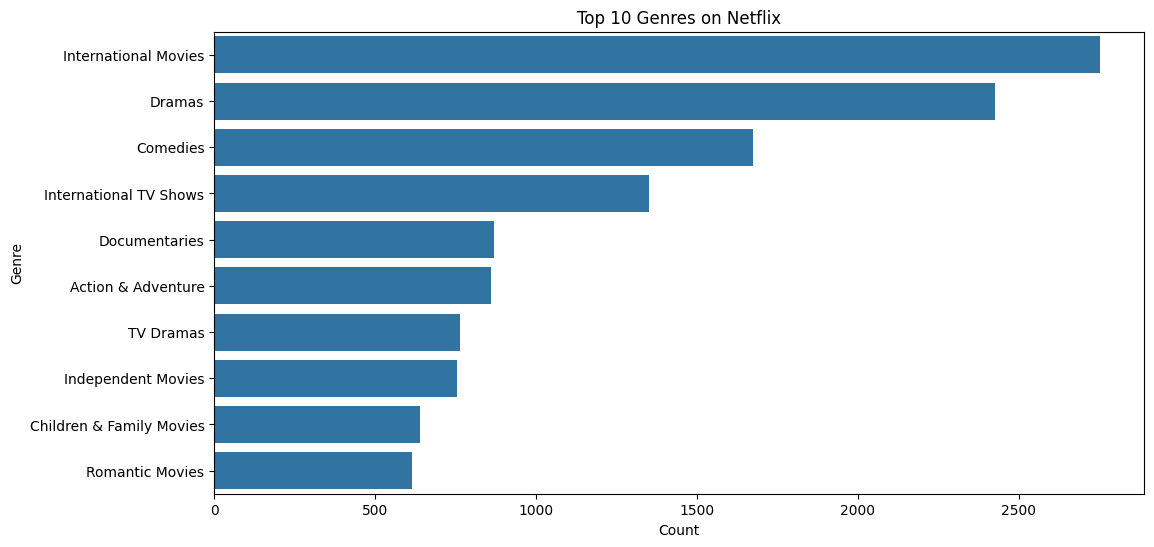

In [18]:
#Genre Analysis
genre = df['listed_in'].str.split(',', expand=True).stack()

genre = genre.str.strip()

top_genres = genre.value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(x=top_genres.values,
            y=top_genres.index)

plt.title('Top 10 Genres on Netflix')
plt.xlabel('Count')
plt.ylabel('Genre')

plt.show()

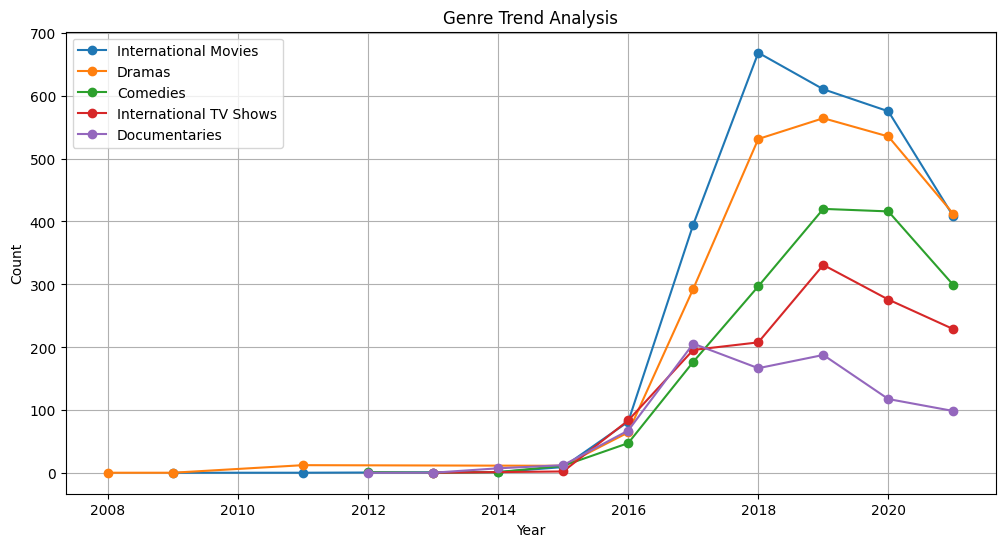

In [19]:
#Genre Trend Analysis
genre_df = df.copy()

genre_df['listed_in'] = genre_df['listed_in'].str.split(',')

genre_df = genre_df.explode('listed_in')

genre_df['listed_in'] = genre_df['listed_in'].str.strip()

genre_trend = genre_df.groupby(
    ['year_added', 'listed_in']
).size().reset_index(name='count')

# Top 5 genres

top_genre_names = genre_df['listed_in'].value_counts().head(5).index

filtered_genre = genre_trend[
    genre_trend['listed_in'].isin(top_genre_names)
]

plt.figure(figsize=(12,6))

for genre in top_genre_names:
    data = filtered_genre[
        filtered_genre['listed_in'] == genre
    ]

    plt.plot(data['year_added'],
             data['count'],
             marker='o',
             label=genre)

plt.title('Genre Trend Analysis')
plt.xlabel('Year')
plt.ylabel('Count')
plt.legend()
plt.grid(True)

plt.show()

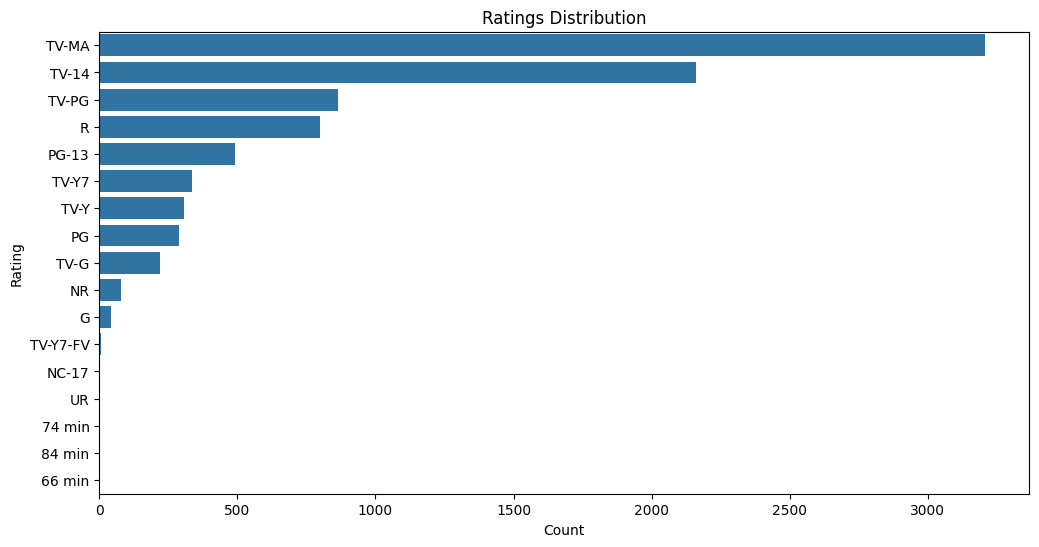

In [20]:
#Rating Analysis
plt.figure(figsize=(12,6))

sns.countplot(y='rating',
              data=df,
              order=df['rating'].value_counts().index)

plt.title('Ratings Distribution')
plt.xlabel('Count')
plt.ylabel('Rating')

plt.show()

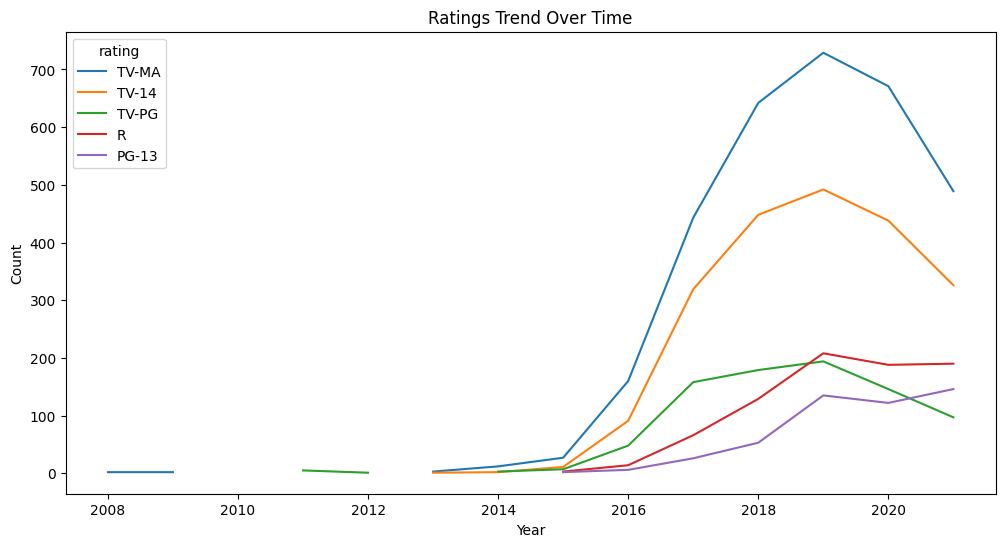

In [21]:
#Ratings Trend Analysis
rating_trend = df.groupby(
    ['year_added', 'rating']
).size().unstack()

# Top 5 ratings

top_ratings = df['rating'].value_counts().head(5).index

rating_trend[top_ratings].plot(figsize=(12,6))

plt.title('Ratings Trend Over Time')
plt.xlabel('Year')
plt.ylabel('Count')

plt.show()

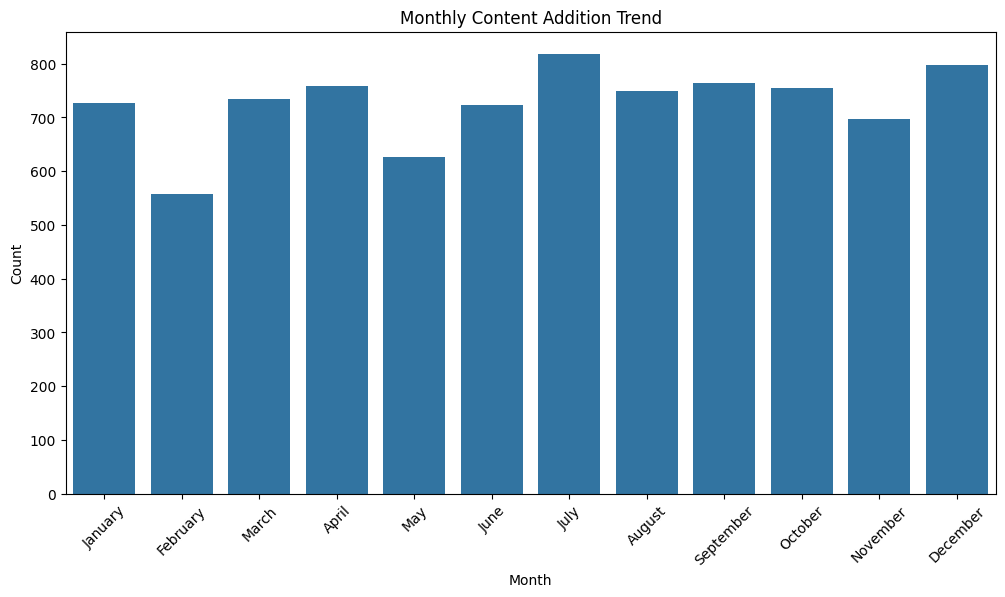

In [22]:
#Monthly Trend Analysis
monthly_content = df['month_added'].value_counts()

month_order = [
    'January', 'February', 'March',
    'April', 'May', 'June',
    'July', 'August', 'September',
    'October', 'November', 'December'
]

monthly_content = monthly_content.reindex(month_order)

plt.figure(figsize=(12,6))

sns.barplot(x=monthly_content.index,
            y=monthly_content.values)

plt.xticks(rotation=45)

plt.title('Monthly Content Addition Trend')
plt.xlabel('Month')
plt.ylabel('Count')

plt.show()

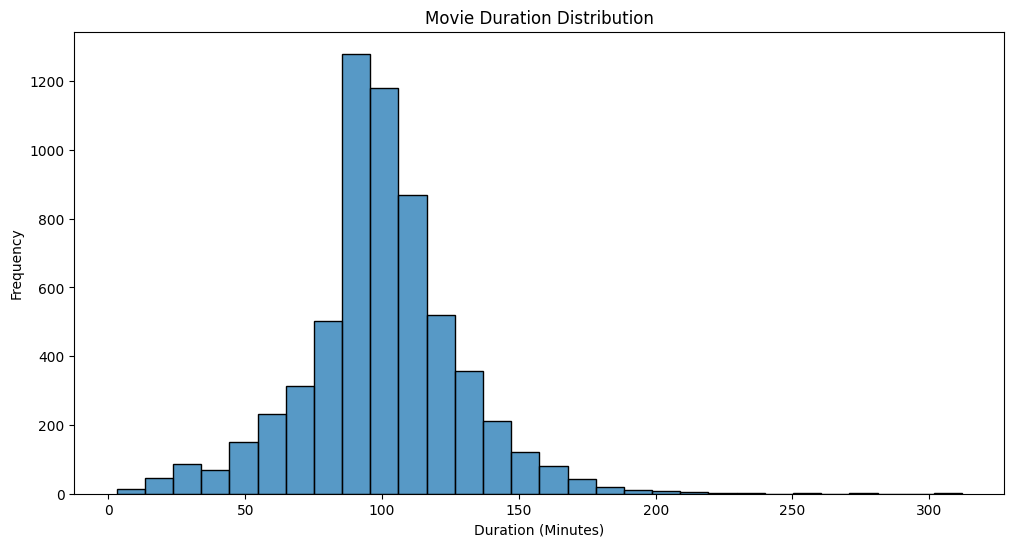

In [23]:
#Movie Duration Analysis
movie_df = df[df['type'] == 'Movie'].copy()

movie_df['duration_int'] = movie_df['duration'] \
    .str.replace(' min', '')

movie_df = movie_df[
    movie_df['duration_int'].str.isnumeric()
]

movie_df['duration_int'] = movie_df['duration_int'].astype(int)

plt.figure(figsize=(12,6))

sns.histplot(movie_df['duration_int'], bins=30)

plt.title('Movie Duration Distribution')
plt.xlabel('Duration (Minutes)')
plt.ylabel('Frequency')

plt.show()

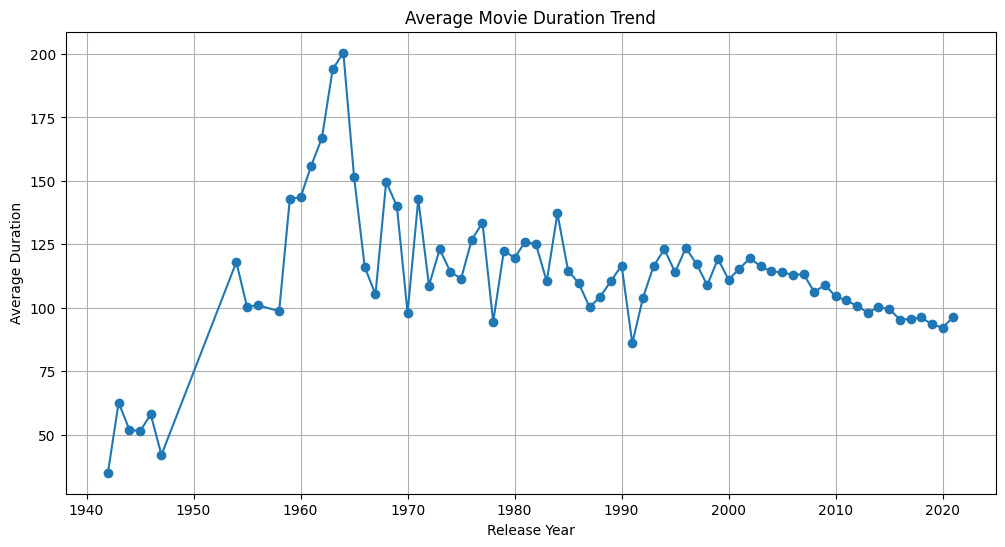

In [24]:
#Average Movie Duration Trend
duration_trend = movie_df.groupby(
    'release_year'
)['duration_int'].mean()

plt.figure(figsize=(12,6))

plt.plot(duration_trend.index,
         duration_trend.values,
         marker='o')

plt.title('Average Movie Duration Trend')
plt.xlabel('Release Year')
plt.ylabel('Average Duration')
plt.grid(True)

plt.show()

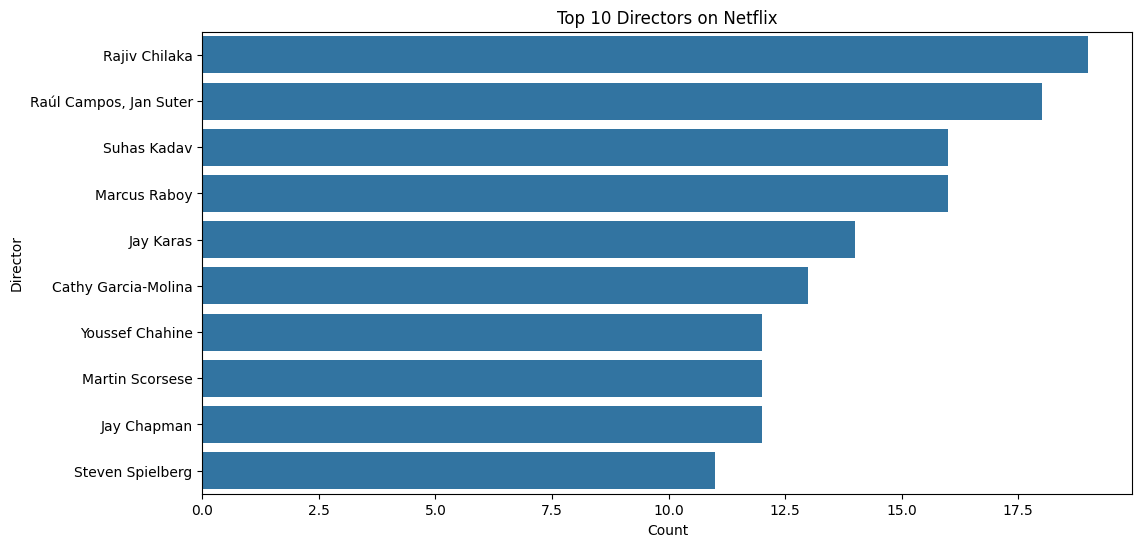

In [25]:
#Top Directors Analysis
director_count = df['director'].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(x=director_count.values,
            y=director_count.index)

plt.title('Top 10 Directors on Netflix')
plt.xlabel('Count')
plt.ylabel('Director')

plt.show()

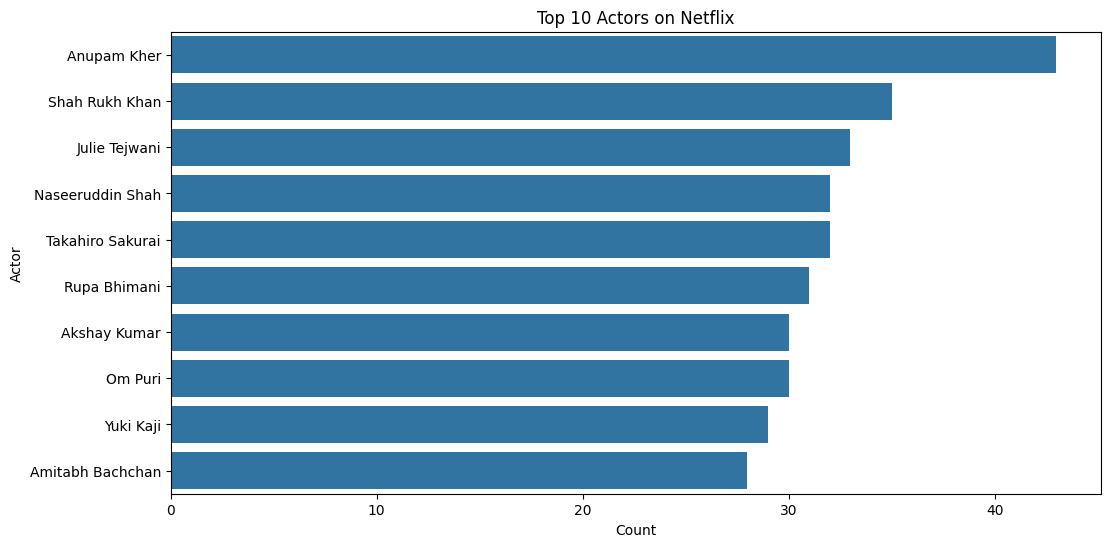

In [26]:
#Top Actors Analysis
cast_df = df.copy()

cast_df['cast'] = cast_df['cast'].str.split(',')

cast_df = cast_df.explode('cast')

cast_df['cast'] = cast_df['cast'].str.strip()

actor_count = cast_df['cast'].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(x=actor_count.values,
            y=actor_count.index)

plt.title('Top 10 Actors on Netflix')
plt.xlabel('Count')
plt.ylabel('Actor')

plt.show()

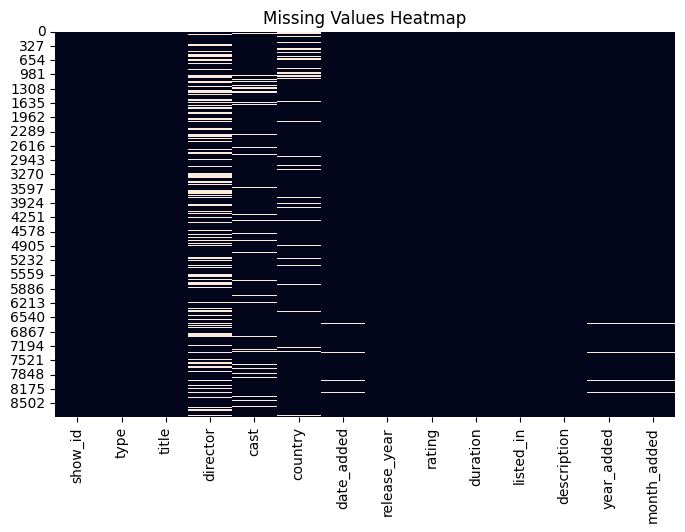

In [27]:
#Heatmap Visualisation
plt.figure(figsize=(8,5))

sns.heatmap(df.isnull(), cbar=False)

plt.title('Missing Values Heatmap')

plt.show()

In [29]:
#Interactive Plotly Visualisation
import plotly.io as pio
pio.renderers.default = 'browser'
interactive_fig = px.line(
    x=yearly_content.index,
    y=yearly_content.values,
    title='Interactive Netflix Content Growth Trend'
)

interactive_fig.show()

In [30]:
#Final insights
print("\nPROJECT INSIGHTS\n")

print("1. Netflix contains more Movies than TV Shows.")

print("2. Netflix content increased rapidly after 2015.")

print("3. USA contributes the highest amount of content.")

print("4. Drama and International genres are dominant.")

print("5. TV-MA is the most common rating category.")

print("6. Netflix expanded globally in recent years.")


PROJECT INSIGHTS

1. Netflix contains more Movies than TV Shows.
2. Netflix content increased rapidly after 2015.
3. USA contributes the highest amount of content.
4. Drama and International genres are dominant.
5. TV-MA is the most common rating category.
6. Netflix expanded globally in recent years.


In [31]:
#Save cleaned Data
df.to_csv('cleaned_netflix_data.csv', index=False)